In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numba import njit

In [2]:
num_part = 1000
np.random.seed(100)
boxL = 5

np.random.seed(100)
x = np.random.random((num_part,2))*boxL
theta = 2*np.pi*np.random.random(num_part)

x_i = x.copy()
theta_i = theta.copy()

In [3]:
@njit
def config_avg_cell(x, theta, r, boxL):
    N = x.shape[0]
    nc = int(boxL / r)
    if nc < 1:
        nc = 1
    cell_size = boxL / nc
    head = -np.ones((nc, nc), dtype=np.int64)
    linked = -np.ones(N, dtype=np.int64)
    # build cell list
    for i in range(N):
        cx = int(x[i,0] / cell_size)
        cy = int(x[i,1] / cell_size)
        if cx >= nc:
            cx = nc - 1
        if cy >= nc:
            cy = nc - 1
        linked[i] = head[cx, cy]
        head[cx, cy] = i
    avgt = np.empty(N, dtype=np.float64)
    r2 = r*r
    for i in range(N):
        cx = int(x[i,0] / cell_size)
        cy = int(x[i,1] / cell_size)
        sx = 0.0
        sy = 0.0
        for dcx in range(-1, 2):
            for dcy in range(-1, 2):
                nx = (cx + dcx) % nc
                ny = (cy + dcy) % nc
                j = head[nx, ny]
                while j != -1:
                    dx = x[i,0] - x[j,0]
                    dy = x[i,1] - x[j,1]
                    # periodic minimum image
                    if dx > 0.5*boxL:
                        dx -= boxL
                    elif dx < -0.5*boxL:
                        dx += boxL
                    if dy > 0.5*boxL:
                        dy -= boxL
                    elif dy < -0.5*boxL:
                        dy += boxL
                    if dx*dx + dy*dy <= r2:
                        sx += np.cos(theta[j])
                        sy += np.sin(theta[j])
                    j = linked[j]
        avgt[i] = np.arctan2(sy, sx)
    return avgt

In [4]:
@njit
def vel_vec(v,theta):
    cos = np.cos(theta)
    sin = np.sin(theta)
    vec = v*np.column_stack((cos,sin))
    return vec

In [5]:
@njit
def evolve_cell(x, theta, nsteps, r, noise, v, dt, boxL):
    N = x.shape[0]
    for step in range(nsteps):
        avgt = config_avg_cell(x, theta, r, boxL)
        for i in range(N):
            theta[i] = avgt[i] + noise*(np.random.random() - 0.5)
            x[i,0] += v*np.cos(theta[i])*dt
            x[i,1] += v*np.sin(theta[i])*dt
            if x[i,0] >= boxL:
                x[i,0] -= boxL
            elif x[i,0] < 0.0:
                x[i,0] += boxL
            if x[i,1] >= boxL:
                x[i,1] -= boxL
            elif x[i,1] < 0.0:
                x[i,1] += boxL
    return x, theta

In [6]:
#Vicsek Parameters
noise = 0.1 #strength of noise
v = 0.5  #Constant Velocity Term
rad_int = 0.1 #Interaction Radius


#Update
t = 500 #time of evolution
dt = 0.01
#sqdt=np.sqrt(dt)
n = int(t/dt)
x,theta = evolve_cell(x,theta,n,rad_int,noise,v,dt,boxL)

In [7]:
@njit
def getY(x,theta,boxL):
    cos = np.cos(theta)
    sin = np.sin(theta)
    m = boxL/25
    trig = m*np.column_stack((cos,sin))
    y1 = x[:,0]+trig[:,0]
    y2 = x[:,1]+trig[:,1]
    y = np.column_stack((y1,y2))
    return y

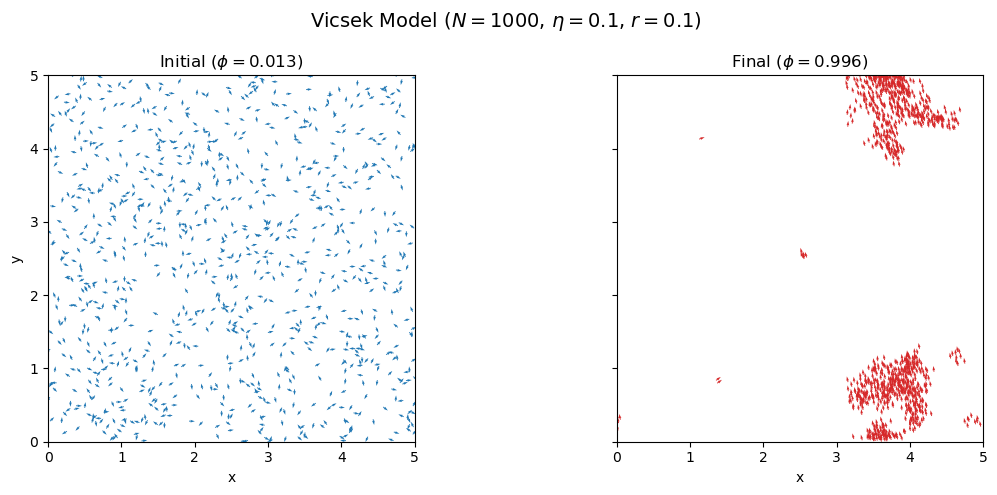

In [8]:
import matplotlib.pyplot as plt

y_i = getY(x_i,theta_i,boxL)
y = getY(x,theta,boxL)

phi0 = np.sqrt(np.mean(np.cos(theta_i))**2 +
               np.mean(np.sin(theta_i))**2)

phi1 = np.sqrt(np.mean(np.cos(theta))**2 +
               np.mean(np.sin(theta))**2)

fig, ax = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)

# Initial state
dx_i = y_i[:,0] - x_i[:,0]
dy_i = y_i[:,1] - x_i[:,1]

ax[0].quiver(
    x_i[:,0], x_i[:,1],
    dx_i, dy_i,
    angles='xy',
    scale_units='xy',
    scale=2.5,
    color='tab:blue'
)

ax[0].set_title(rf"Initial ($\phi={phi0:.3f}$)")
ax[0].set_xlabel("x")
ax[0].set_ylabel("y")
ax[0].set_aspect('equal')

# Final state
dx = y[:,0] - x[:,0]
dy = y[:,1] - x[:,1]

ax[1].quiver(
    x[:,0], x[:,1],
    dx, dy,
    angles='xy',
    scale_units='xy',
    scale=2.5,
    color='tab:red'
)

ax[1].set_title(rf"Final ($\phi={phi1:.3f}$)")
ax[1].set_xlabel("x")
ax[1].set_aspect('equal')

# Common limits
for a in ax:
    a.set_xlim(0, boxL)
    a.set_ylim(0, boxL)

fig.suptitle(
    rf"Vicsek Model ($N={len(x)}$, $\eta={noise}$, $r={rad_int}$)",
    fontsize=14
)

plt.tight_layout()
plt.show()

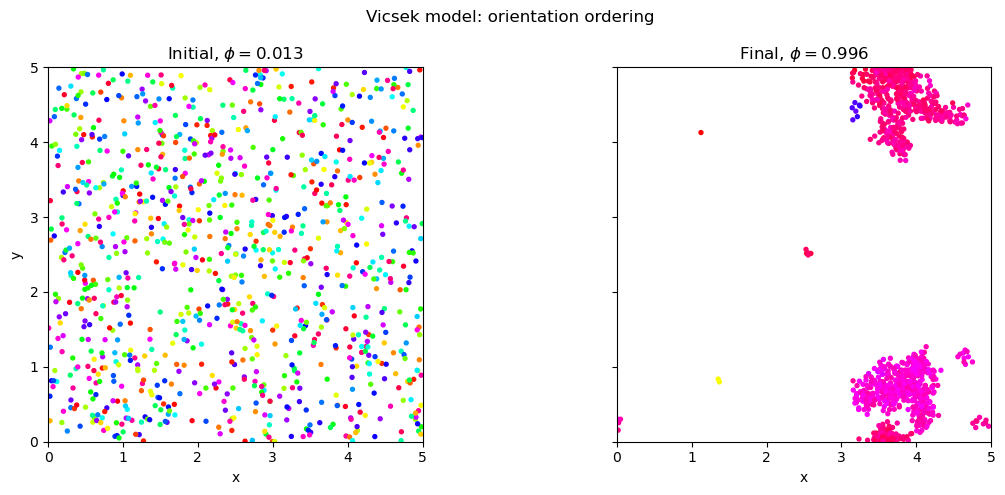

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(12,5), sharex=True, sharey=True)

theta_i_color = theta_i % (2*np.pi)
theta_color   = theta % (2*np.pi)

ax[0].scatter(x_i[:,0], x_i[:,1], c=theta_i_color, cmap="hsv", s=8)
ax[0].set_title(rf"Initial, $\phi={phi0:.3f}$")

sc = ax[1].scatter(x[:,0], x[:,1], c=theta_color, cmap="hsv", s=8)
ax[1].set_title(rf"Final, $\phi={phi1:.3f}$")

for a in ax:
    a.set_xlim(0, boxL)
    a.set_ylim(0, boxL)
    a.set_aspect("equal")
    a.set_xlabel("x")

ax[0].set_ylabel("y")

fig.suptitle(r"Vicsek model: orientation ordering")
plt.tight_layout()
plt.show()